# Estimación de probabilidades de campeonato del Mundial FIFA 2026 mediante simulación de Monte Carlo basada en ratings Elo

**Autor:** Gus (`gvar1965`) · Carrera de Especialización en Inteligencia Artificial (CEIA), FIUBA — *Análisis de Datos*
**Fecha:** junio de 2026

---

### Resumen

Se estima la probabilidad de que cada una de las 48 selecciones se consagre campeona del
Mundial FIFA 2026 mediante **simulación de Monte Carlo**, partiendo del estado del torneo en
curso (mitad de la fase de grupos). Cada partido se modela con dos distribuciones de Poisson
independientes cuyas intensidades se derivan de la diferencia de **rating Elo** entre los
contendientes, calibradas de modo que el cociente de goles esperados reproduzca la forma
clásica del Elo. A partir del estado actual de los 12 grupos se simulan los encuentros
restantes, la clasificación (dos primeros de cada grupo más los ocho mejores terceros) y la
totalidad de la fase eliminatoria respetando la plantilla oficial de la Ronda de 32. Sobre
$N=10^{6}$ réplicas independientes se obtiene que **Argentina** ($28{,}6\%$), **Francia**
($25{,}7\%$), **España** ($14{,}3\%$) e **Inglaterra** ($12{,}0\%$) concentran cerca del
$80\%$ de los títulos. Se reportan los **errores estándar de Monte Carlo** e
**intervalos de confianza del 95\%**, se verifica la **convergencia** del estimador y se
analiza la **sensibilidad** a la ventaja de localía. La implementación del motor utiliza
únicamente la biblioteca estándar de Python y es íntegramente reproducible (semilla fija,
entorno fijado con `uv`).

**Palabras clave:** Monte Carlo · rating Elo · modelo de Poisson · pronóstico deportivo ·
Mundial 2026 · simulación estocástica.

## 1. Introducción

El pronóstico de resultados en fútbol de selecciones combina dos ingredientes bien estudiados
en la literatura: un **sistema de rating** que sintetiza la fuerza relativa de los equipos y un
**modelo generativo de goles** que traduce esa fuerza en marcadores. El rating Elo, originado
en ajedrez [1] y adaptado al fútbol por *eloratings.net* [6], ha mostrado capacidad predictiva
competitiva frente a otros sistemas de ranking [4, 5]. Por su parte, el modelado de goles
mediante distribuciones de Poisson se remonta a Maher [2] y fue refinado por Dixon y Coles [3].

El Mundial 2026 introduce un formato inédito de **48 selecciones** en 12 grupos, con
clasificación de los dos primeros de cada grupo y los ocho mejores terceros, seguido de una
fase eliminatoria de 32 equipos [8]. Este trabajo aborda la pregunta: *dado el estado actual
del torneo, ¿con qué probabilidad se consagra campeona cada selección?* Dada la complejidad
combinatoria de la fase final, una solución analítica cerrada es impracticable; se recurre
entonces a **simulación de Monte Carlo** [9].

**Contribución.** Se presenta (i) un modelo de partido Elo→Poisson calibrado y parsimonioso,
(ii) una simulación íntegra del torneo desde su estado actual hasta la final respetando el
*bracket* oficial, y (iii) una estimación de las probabilidades de campeonato con
cuantificación rigurosa del error de Monte Carlo, análisis de convergencia y de sensibilidad.

## 2. Datos

Se emplean cuatro insumos (directorio `data/`), correspondientes a un *snapshot* del torneo
tomado alrededor del **20 de junio de 2026**:

| Insumo | Descripción | Fuente |
|--------|-------------|--------|
| `elo.csv`      | Rating Elo de las 48 selecciones (escala clásica) | worldfootballrankings [7] |
| `groups.csv`   | Posiciones actuales de los 12 grupos (PJ, Pts, GF, GC) | CBS Sports [10], NBC Sports [11] |
| `fixtures.csv` | Partidos de grupo aún no disputados | CBS Sports [10] |
| `bracket.json` | Plantilla oficial de la Ronda de 32 y llave hasta la final | worldcuppass [12] |

Trece selecciones menores sin Elo publicado en la misma escala reciben un valor **estimado**
(columna `fuente` en `elo.csv`); el impacto de esta aproximación sobre las favoritas es
despreciable (Sección 5).

In [1]:
import time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import wcsim

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
Z95 = 1.959963985  # cuantil normal estandar para IC del 95%

data = wcsim.load_all()
elo, groups, fixtures, bracket = data["elo"], data["groups"], data["fixtures"], data["bracket"]
print(f"{len(elo)} selecciones · {len(groups)} grupos · "
      f"{len(fixtures)} partidos de grupo por jugar · "
      f"{len(bracket['r32'])} cruces en la Ronda de 32")

elo_df = pd.DataFrame(sorted(elo.items(), key=lambda x: -x[1]), columns=["Selección", "Elo"])
print("\nTop-10 por Elo:")
display(elo_df.head(10).style.format({"Elo": "{:.0f}"}).hide(axis="index"))

48 selecciones · 12 grupos · 40 partidos de grupo por jugar · 16 cruces en la Ronda de 32

Top-10 por Elo:


Selección,Elo
Argentina,1889
France,1887
Spain,1856
England,1848
Brazil,1772
Morocco,1770
Netherlands,1764
Portugal,1755
Germany,1744
Belgium,1734


## 3. Metodología

### 3.1 Sistema de rating Elo

A cada selección $i$ se le asocia un rating $R_i \in \mathbb{R}$. Para un enfrentamiento entre
$A$ y $B$, el Elo define el **puntaje esperado** de $A$ (con el empate valuado en medio punto)
como función exclusiva de la diferencia $\Delta = R_A - R_B$:

$$E_A(\Delta) \;=\; \frac{1}{1 + 10^{-\Delta/400}}, \qquad E_B = 1 - E_A. \tag{1}$$

La constante $400$ fija la escala: una ventaja de $\Delta = 400$ implica $E_A \approx 0{,}91$.
Las sedes (USA, México, Canadá) reciben una **ventaja de localía** $h$ ($=60$ por defecto)
solo cuando juegan **en su propio país**:

$$\tilde R_i = R_i + h\,\mathbb{1}\{\text{la sede del partido está en el país de } i\}.$$

En la fase de grupos cada anfitrión juega de local; en la fase eliminatoria la sede está
fijada por número de partido según el calendario oficial [13] (`venue` en `bracket.json`), de
modo que un anfitrión puede jugar fuera de su país: la final y todas las rondas desde cuartos
se disputan en EE. UU., mientras que solo seis cruces de las primeras rondas ocurren en México
(M75, M79, M92) o Canadá (M83, M85, M96).

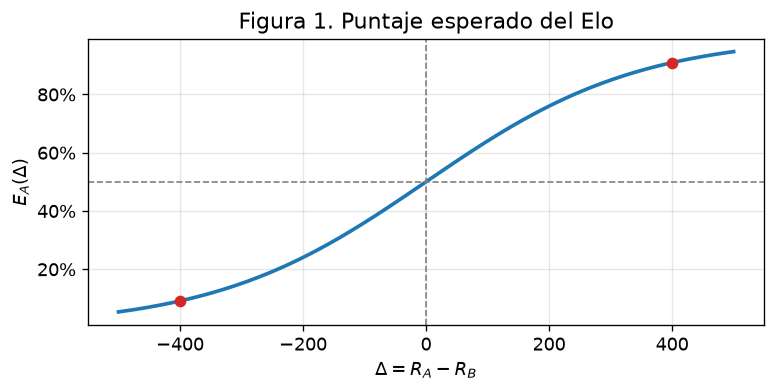

In [2]:
# Figura 1 — funcion logistica del Elo (Ec. 1)
d = np.linspace(-500, 500, 400)
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(d, 1/(1+10**(-d/400)), lw=2.2, color="#1f77b4")
ax.axhline(0.5, color="grey", ls="--", lw=1); ax.axvline(0, color="grey", ls="--", lw=1)
ax.scatter([400, -400], [1/(1+10**(-400/400)), 1/(1+10**(400/400))], color="#d62728", zorder=5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel(r"$\Delta = R_A - R_B$"); ax.set_ylabel(r"$E_A(\Delta)$")
ax.set_title("Figura 1. Puntaje esperado del Elo")
plt.tight_layout(); plt.savefig("charts/01_curva_elo.png", bbox_inches="tight"); plt.show()

### 3.2 Modelo generativo de partido (Elo → Poisson)

El puntaje esperado (Ec. 1) no produce un **marcador**, necesario para los criterios de
desempate de la fase de grupos. Siguiendo la tradición de Maher [2] y Dixon–Coles [3],
modelamos los goles de cada equipo como variables de Poisson independientes:

$$G_A \sim \text{Poisson}(\lambda_A), \qquad G_B \sim \text{Poisson}(\lambda_B), \tag{2}$$

con intensidades derivadas de la diferencia de Elo $\tilde\Delta = \tilde R_A - \tilde R_B$:

$$\lambda_A = \mu \cdot 10^{\,\tilde\Delta/800}, \qquad
  \lambda_B = \mu \cdot 10^{-\tilde\Delta/800}. \tag{3}$$

El parámetro $\mu = 1{,}35$ es el nivel de goles esperados entre rivales parejos
($\tilde\Delta=0$). La elección del exponente $\pm\tilde\Delta/800$ es deliberada: implica

$$\frac{\lambda_A}{\lambda_B} = 10^{\,\tilde\Delta/400}, \tag{4}$$

es decir, el **cociente de goles esperados reproduce la escala del Elo clásico** (Ec. 1),
manteniendo además el total esperado $\lambda_A\lambda_B = \mu^2$ aproximadamente invariante.
El empate emerge endógenamente cuando $G_A = G_B$. En la fase eliminatoria, un empate se
resuelve por penales asignando la victoria a $A$ con probabilidad $E_A(\tilde\Delta)$.

Dado el modelo (2), las probabilidades de victoria/empate/derrota se obtienen analíticamente:

$$P(G_A > G_B),\; P(G_A = G_B),\; P(G_A < G_B)
  \;=\; \sum_{a,b\ge 0} \frac{e^{-\lambda_A}\lambda_A^{a}}{a!}\,
  \frac{e^{-\lambda_B}\lambda_B^{b}}{b!}\;\mathbb{1}\{\cdot\}. \tag{5}$$

Partido,λ_A,λ_B,P(gana A),P(empate),P(gana B)
Argentina – Brazil,1.890000,0.960000,59.1%,22.1%,18.8%
Spain – England,1.380000,1.320000,38.6%,25.8%,35.6%
France – USA,1.890000,0.960000,59.2%,22.1%,18.7%
Mexico – Germany,1.510000,1.210000,44.1%,25.4%,30.5%
Morocco – Croatia,1.670000,1.090000,51.0%,24.2%,24.7%


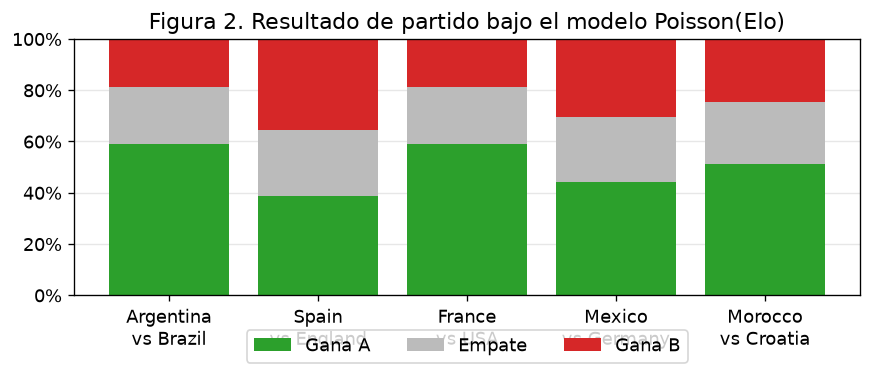

In [3]:
# Ec. (5): probabilidades G/E/P analiticas a partir de las intensidades de Poisson
def pois_pmf(k, lam):
    return math.exp(-lam) * lam**k / math.factorial(k)

def wdl(a, b, model, maxg=25):
    la, lb = model.lambdas(a, b)
    pa = [pois_pmf(k, la) for k in range(maxg)]
    pb = [pois_pmf(k, lb) for k in range(maxg)]
    win  = sum(pa[i]*pb[j] for i in range(maxg) for j in range(maxg) if i > j)
    draw = sum(pa[i]*pb[i] for i in range(maxg))
    loss = sum(pa[i]*pb[j] for i in range(maxg) for j in range(maxg) if i < j)
    total = win + draw + loss   # normaliza y absorbe el residuo de las colas truncadas
    return win/total, draw/total, loss/total

model = wcsim.MatchModel(elo)
pares = [("Argentina","Brazil"),("Spain","England"),("France","USA"),
         ("Mexico","Germany"),("Morocco","Croatia")]
rows = []
for a, b in pares:
    la, lb = model.lambdas(a, b); w, dr, l = wdl(a, b, model)
    rows.append([f"{a} – {b}", round(la,2), round(lb,2), w, dr, l])
tab = pd.DataFrame(rows, columns=["Partido","λ_A","λ_B","P(gana A)","P(empate)","P(gana B)"])
display(tab.style.format({"P(gana A)":"{:.1%}","P(empate)":"{:.1%}","P(gana B)":"{:.1%}"}).hide(axis="index"))

# Figura 2 — descomposicion G/E/P
W=[r[3] for r in rows]; D=[r[4] for r in rows]; L=[r[5] for r in rows]
labels=[f"{a}\nvs {b}" for a,b in pares]
fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.bar(labels, W, label="Gana A", color="#2ca02c")
ax.bar(labels, D, bottom=W, label="Empate", color="#bbbbbb")
ax.bar(labels, L, bottom=[w+d for w,d in zip(W,D)], label="Gana B", color="#d62728")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0,1)
ax.set_title("Figura 2. Resultado de partido bajo el modelo Poisson(Elo)")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5,-0.30))
plt.tight_layout(); plt.savefig("charts/02_partido_gep.png", bbox_inches="tight"); plt.show()

### 3.3 Estructura del torneo

**Fase de grupos.** Se parte del estado observado de cada grupo (puntos, GF, GC acumulados) y
se simulan únicamente los partidos restantes según (2)–(3). El ordenamiento final de cada grupo
sigue los criterios oficiales aproximados: **puntos → diferencia de gol → goles a favor**, con
el Elo como desempate residual. Clasifican los dos primeros de cada grupo (24 equipos) y los
**ocho mejores terceros** entre los doce, ordenados por el mismo criterio.

**Fase eliminatoria.** Los 32 clasificados se ubican en la **Ronda de 32 oficial**
(`bracket.json`, partidos M73–M88): cada posición está predeterminada como *ganador de grupo*,
*segundo* o *mejor tercero*. Los ocho terceros se asignan a sus ranuras respetando los grupos
admitidos por cada una mediante un *matching* bipartito (algoritmo de Kuhn). La llave se
resuelve partido a partido hasta la final:

$$\text{R32}\,(16) \to \text{8vos}\,(8) \to \text{4tos}\,(4) \to \text{SF}\,(2) \to \text{Final}\,(1).$$

In [4]:
# Una realizacion del torneo (verificacion cualitativa del motor)
rng_demo = random.Random(7)
st, thirds = wcsim.simulate_group_stage(groups, fixtures, model, rng_demo)
champ, fin, sem = wcsim.simulate_knockout(st, thirds, bracket, model, rng_demo)
print("Realización de ejemplo (semilla 7):")
print("  Campeón        :", champ)
print("  Finalistas     :", " y ".join(fin))
print("  Semifinalistas :", ", ".join(sem))

Realización de ejemplo (semilla 7):
  Campeón        : Morocco
  Finalistas     : Morocco y USA
  Semifinalistas : Morocco, England, USA, Iran


### 3.4 Estimador de Monte Carlo

Sea $X^{(k)}$ la realización $k$-ésima del torneo y $\mathbb{1}\{X^{(k)}=i\}$ el indicador de
que la selección $i$ resulte campeona. El estimador de la probabilidad de campeonato es la
proporción muestral sobre $N$ réplicas independientes:

$$\hat p_i \;=\; \frac{1}{N}\sum_{k=1}^{N} \mathbb{1}\{X^{(k)} = i\}. \tag{6}$$

Por la ley de los grandes números $\hat p_i \to p_i$ y, al ser $\hat p_i$ una proporción
binomial, su **error estándar de Monte Carlo** y su **intervalo de confianza del 95\%** son

$$\operatorname{SE}(\hat p_i) = \sqrt{\frac{\hat p_i(1-\hat p_i)}{N}}, \qquad
  \text{IC}_{95\%} = \hat p_i \pm z_{0.975}\,\operatorname{SE}(\hat p_i). \tag{7}$$

El error decrece como $\mathcal{O}(N^{-1/2})$. Con $N=10^{6}$, para $\hat p \approx 0{,}28$ se
tiene $\operatorname{SE} \approx 4{,}5\times 10^{-4}$ (es decir, $\pm 0{,}09$ puntos
porcentuales con 95\% de confianza), por lo que la incertidumbre estadística es despreciable
frente a la incertidumbre de modelado.

## 4. Resultados

### 4.1 Probabilidades de campeonato

Se ejecutan $N=10^{6}$ réplicas con semilla fija (`seed=2026`). Para cada selección se registra,
además del título, el avance hasta semifinal y final, lo que permite trazar todo el recorrido
por la grilla. El siguiente bloque realiza una **única pasada** que acumula los conteos (Ec. 6)
y, simultáneamente, almacena estimaciones parciales en puntos de control para el análisis de
convergencia (Sección 4.3).

In [5]:
def run_tracked(N, seed, track, checkpoints, base=1.35, home_adv=60.0):
    # Una pasada de N torneos: devuelve conteos finales + trayectoria de p_i.
    m = wcsim.MatchModel(elo, base=base, home_adv=home_adv)
    rng = random.Random(seed)
    teams = list(elo)
    champ = {t: 0 for t in teams}; final = {t: 0 for t in teams}; semi = {t: 0 for t in teams}
    cps = sorted(checkpoints); xs = []; traj = {t: [] for t in track}; ci = 0
    for i in range(1, N + 1):
        s, th = wcsim.simulate_group_stage(groups, fixtures, m, rng)
        c, f2, s2 = wcsim.simulate_knockout(s, th, bracket, m, rng)
        champ[c] += 1
        for f in f2: final[f] += 1
        for s3 in s2: semi[s3] += 1
        if ci < len(cps) and i == cps[ci]:
            xs.append(i)
            for t in track: traj[t].append(champ[t] / i)
            ci += 1
    return champ, final, semi, xs, traj

N = 1_000_000
TRACK = ["Argentina", "France", "Spain", "England"]
CPS = [1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]

t0 = time.perf_counter()
champ, final, semi, xs, traj = run_tracked(N, 2026, TRACK, CPS)
dt = time.perf_counter() - t0
print(f"N = {N:,} torneos simulados en {dt:.1f} s  ({N/dt:,.0f} torneos/s)")

N = 1,000,000 torneos simulados en 60.3 s  (16,589 torneos/s)


In [6]:
# Tabla 1 — probabilidades con SE e IC95 (Ecs. 6-7)
recs = []
for t in elo:
    k = champ[t]; p = k / N
    se = math.sqrt(p * (1 - p) / N)
    recs.append({"Selección": t, "Elo": elo[t], "Títulos": k, "p̂(campeón)": p,
                 "SE": se, "IC95_lo": p - Z95*se, "IC95_hi": p + Z95*se,
                 "p̂(final)": final[t]/N, "p̂(semi)": semi[t]/N})
df = pd.DataFrame(recs).sort_values("Títulos", ascending=False).reset_index(drop=True)
ncamp = int((df["Títulos"] > 0).sum())
print(f"{ncamp} de {len(elo)} selecciones se consagraron campeonas en al menos un escenario.\n")

def fmt_ci(r):
    return f"[{r['IC95_lo']*100:.2f}; {r['IC95_hi']*100:.2f}]"
show = df.head(15).copy()
show["IC95% (campeón) %"] = show.apply(fmt_ci, axis=1)
cols = ["Selección","Elo","Títulos","p̂(campeón)","IC95% (campeón) %","p̂(final)","p̂(semi)"]
display(show[cols].style.format({"Elo":"{:.0f}","Títulos":"{:,}","p̂(campeón)":"{:.2%}",
        "p̂(final)":"{:.1%}","p̂(semi)":"{:.1%}"}).hide(axis="index")
        .set_caption("Tabla 1. Probabilidades estimadas de campeonato (N = 10⁶, seed 2026)."))

33 de 48 selecciones se consagraron campeonas en al menos un escenario.



Selección,Elo,Títulos,p̂(campeón),IC95% (campeón) %,p̂(final),p̂(semi)
Argentina,1889,"286,283",28.63%,[28.54; 28.72],46.7%,68.0%
France,1887,"256,477",25.65%,[25.56; 25.73],43.3%,62.2%
Spain,1856,"142,533",14.25%,[14.18; 14.32],26.2%,47.5%
England,1848,"119,865",11.99%,[11.92; 12.05],23.4%,44.7%
USA,1710,"37,903",3.79%,[3.75; 3.83],10.2%,27.5%
Morocco,1770,"29,455",2.95%,[2.91; 2.98],8.2%,20.2%
Brazil,1772,"29,155",2.92%,[2.88; 2.95],8.1%,19.7%
Portugal,1755,"20,506",2.05%,[2.02; 2.08],6.0%,15.5%
Netherlands,1764,"19,618",1.96%,[1.93; 1.99],5.6%,13.5%
Germany,1744,"13,972",1.40%,[1.37; 1.42],4.5%,11.7%


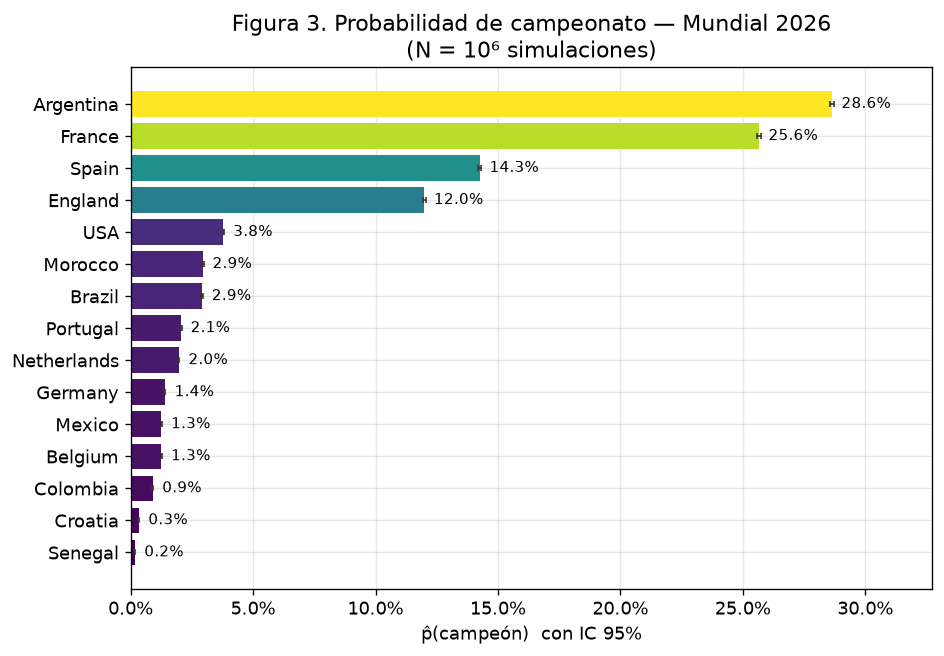

In [7]:
# Figura 3 — p(campeon) top-15 con barras de error IC95 (muy estrechas: SE despreciable)
top = df.head(15).iloc[::-1]
err = Z95 * top["SE"]
fig, ax = plt.subplots(figsize=(8, 5.6))
bars = ax.barh(top["Selección"], top["p̂(campeón)"], xerr=err, capsize=2,
               color=plt.cm.viridis(top["p̂(campeón)"]/top["p̂(campeón)"].max()),
               error_kw={"ecolor":"#333","elinewidth":1})
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("p̂(campeón)  con IC 95%")
ax.set_title("Figura 3. Probabilidad de campeonato — Mundial 2026\n(N = 10⁶ simulaciones)")
for b, v in zip(bars, top["p̂(campeón)"]):
    ax.text(v + 0.004, b.get_y()+b.get_height()/2, f"{v*100:.1f}%", va="center", fontsize=9)
ax.margins(x=0.14)
plt.tight_layout(); plt.savefig("charts/03_campeon_top15.png", bbox_inches="tight"); plt.show()

### 4.2 Avance por la grilla de eliminatorias

La Figura 4 descompone el desempeño de las doce principales selecciones en sus probabilidades
de alcanzar semifinal, final y título, evidenciando que la simulación recorre la **llave
completa** y no solo el partido decisivo.

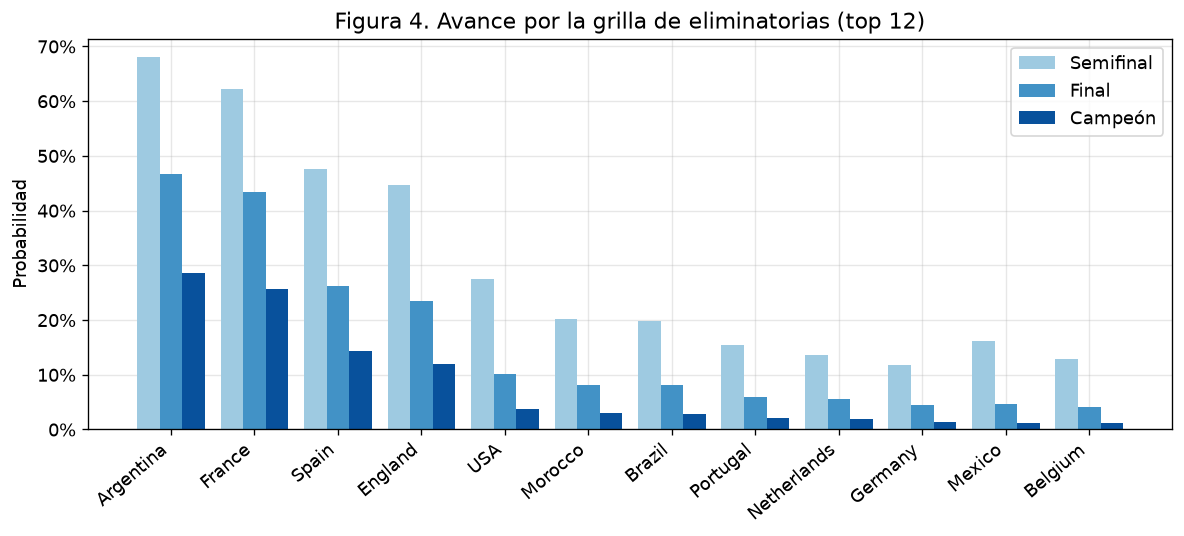

In [8]:
top12 = df.head(12)
x = np.arange(len(top12)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - w, top12["p̂(semi)"],  w, label="Semifinal", color="#9ecae1")
ax.bar(x,     top12["p̂(final)"], w, label="Final",     color="#4292c6")
ax.bar(x + w, top12["p̂(campeón)"], w, label="Campeón", color="#08519c")
ax.set_xticks(x); ax.set_xticklabels(top12["Selección"], rotation=40, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel("Probabilidad")
ax.set_title("Figura 4. Avance por la grilla de eliminatorias (top 12)"); ax.legend()
plt.tight_layout(); plt.savefig("charts/04_avance_grilla.png", bbox_inches="tight"); plt.show()

### 4.3 Convergencia del estimador

La Figura 5(a) muestra la trayectoria de $\hat p_i$ (Ec. 6) frente al número de réplicas $N$
para las cuatro favoritas: las estimaciones se estabilizan claramente a partir de
$N \sim 10^{5}$. La Figura 5(b) verifica que el error estándar (Ec. 7) decae con la pendiente
teórica $N^{-1/2}$ (recta de referencia), confirmando el comportamiento esperado del estimador
de Monte Carlo.

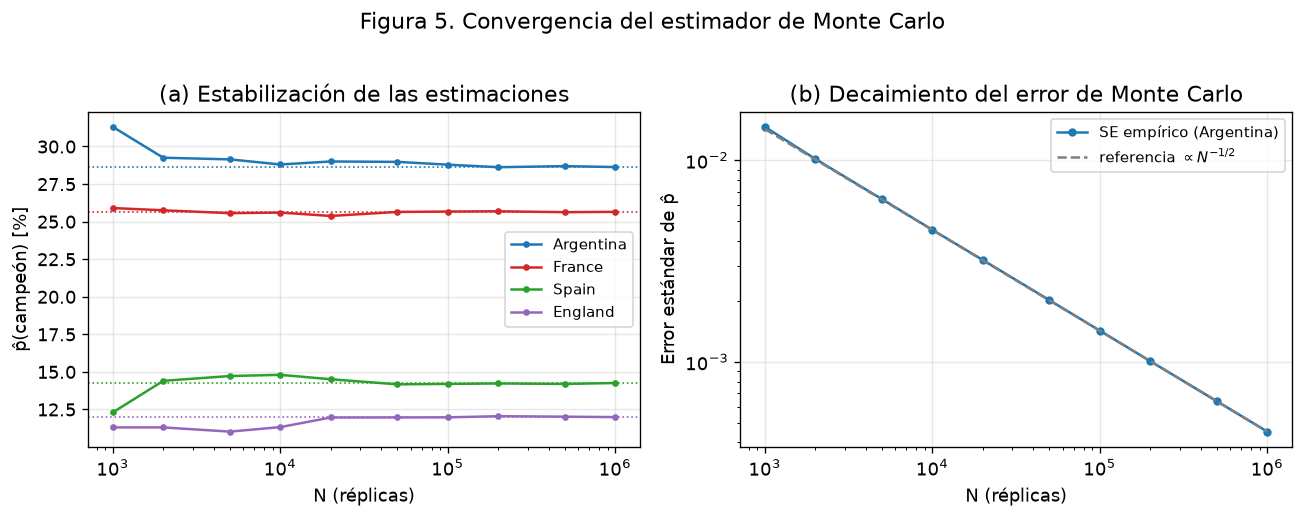

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
colores = {"Argentina":"#1f77b4","France":"#d62728","Spain":"#2ca02c","England":"#9467bd"}
for t in TRACK:
    a1.plot(xs, np.array(traj[t])*100, marker="o", ms=3, color=colores[t], label=t)
    a1.axhline(df.loc[df["Selección"]==t,"p̂(campeón)"].iloc[0]*100, color=colores[t], ls=":", lw=1)
a1.set_xscale("log"); a1.set_xlabel("N (réplicas)"); a1.set_ylabel("p̂(campeón) [%]")
a1.set_title("(a) Estabilización de las estimaciones"); a1.legend(fontsize=9)

# (b) SE vs N para Argentina + recta de referencia ~ N^{-1/2}
pA = df.loc[df["Selección"]=="Argentina","p̂(campeón)"].iloc[0]
se_emp = [math.sqrt((tj)*(1-tj)/n) for n, tj in zip(xs, traj["Argentina"])]
ref = [math.sqrt(pA*(1-pA)/n) for n in xs]
a2.loglog(xs, se_emp, "o-", ms=4, color="#1f77b4", label="SE empírico (Argentina)")
a2.loglog(xs, ref, "--", color="grey", label=r"referencia $\propto N^{-1/2}$")
a2.set_xlabel("N (réplicas)"); a2.set_ylabel("Error estándar de p̂")
a2.set_title("(b) Decaimiento del error de Monte Carlo"); a2.legend(fontsize=9)
fig.suptitle("Figura 5. Convergencia del estimador de Monte Carlo", y=1.02)
plt.tight_layout(); plt.savefig("charts/06_convergencia.png", bbox_inches="tight"); plt.show()

### 4.4 Análisis de sensibilidad

El único parámetro sustantivamente discutible es la ventaja de localía $h$ otorgada a las
sedes. La Tabla 2 reporta $\hat p_i$ (con $N=2\times10^{5}$ por configuración) para
$h\in\{0,\,60,\,120\}$. El ordenamiento de las favoritas es **robusto**: el efecto de $h$ se
concentra, como cabe esperar, en USA y México, sin alterar la jerarquía global.

In [10]:
HS = [0, 60, 120]; teams_show = ["Argentina","France","Spain","England","USA","Mexico","Brazil","Morocco"]
sens = {}
for h in HS:
    res, _ = wcsim.run(n=200_000, seed=2026, home_adv=h)
    sens[h] = {r["team"]: r["p_champion"] for r in res}
sdf = pd.DataFrame({f"h = {h}": [sens[h][t] for t in teams_show] for h in HS}, index=teams_show)
display(sdf.style.format("{:.2%}").set_caption(
    "Tabla 2. Sensibilidad de p̂(campeón) a la ventaja de localía h (N = 2·10⁵)."))

,h = 0,h = 60,h = 120
Argentina,28.85%,28.62%,27.51%
France,25.09%,25.68%,25.62%
Spain,15.46%,14.22%,12.29%
England,14.01%,12.05%,9.45%
USA,1.09%,3.85%,10.00%
Mexico,0.84%,1.22%,1.68%
Brazil,2.84%,2.88%,2.96%
Morocco,2.76%,2.96%,2.92%


## 5. Discusión

Los resultados ubican a **Argentina** y **Francia** netamente por encima del resto, seguidas
por **España** e **Inglaterra**; las cuatro acumulan $\approx 80\%$ de los títulos, en línea
con su Elo (las cuatro de mayor rating) y con el favoritismo del consenso futbolístico.
**USA** supera lo que sugeriría su Elo puro porque juega de local en casi todo el cuadro —la
final y las rondas desde cuartos se disputan íntegramente en EE. UU.— y por su llave favorable
tras ganar el grupo. **México**, en cambio, alcanza con frecuencia las rondas intermedias —es
local en sus sedes de la Ronda de 32 y octavos, con $P(\text{semi})\approx 16\%$ (Figura 4)—
pero su probabilidad de título cae marcadamente ($\approx 1{,}3\%$) al perder la localía en las
rondas finales; este contraste es justamente lo que captura la localía **geográfica** y que un
bonus incondicional ocultaría.

**Validez estadística.** Los intervalos de la Tabla 1 y la Figura 5 muestran que, con
$N=10^{6}$, el error de Monte Carlo es de centésimas de punto porcentual: las estimaciones son
estadísticamente nítidas. El factor limitante es, por lo tanto, el **modelo**, no el muestreo.

**Limitaciones.** (i) El Elo es un proxy de fuerza que no captura lesiones, suspensiones ni
estado de forma puntual. (ii) Los goles se modelan como Poisson **independientes**, ignorando
la correlación intra-partido y la dependencia del marcador documentada por Dixon–Coles [3].
(iii) La asignación de terceros emplea un *matching* válido por grupos admitidos en lugar de la
tabla FIFA exacta de 495 combinaciones, un efecto de segundo orden sobre la identidad del
campeón. (iv) Trece ratings de selecciones menores son estimados. (v) Los parámetros $\mu$ y la
escala $800$ no fueron calibrados por máxima verosimilitud sobre datos históricos, sino fijados
para reproducir la escala del Elo; una calibración formal (p. ej. Poisson bivariado de
Dixon–Coles) es una extensión natural. (vi) Como $\lambda_A + \lambda_B$ crece con
$|\tilde\Delta|$ (Ec. 3), el modelo **sobreestima los goles totales en duelos muy desparejos**
($\approx 7{,}8$ goles esperados para $\tilde\Delta=600$ frente a $2{,}7$ en uno parejo), lo
que afecta sobre todo los desempates por diferencia de gol en la fase de grupos; una compresión
de las colas de $\lambda$ o un mapeo tipo **Skellam** lo mitigaría a costa de relajar la
calibración exacta del Elo. (vii) La ventaja de localía $h$ se aplica a las sedes de forma
**por país de la sede** de cada partido (un anfitrión solo es local en su propio país); no se
modela el apoyo regional ni de la diáspora en estadios neutrales —p. ej. la hinchada mexicana
en sedes de EE. UU.—, que el modelo trata como neutrales.

## 6. Conclusiones

Se estimaron, mediante simulación de Monte Carlo desde el estado actual del Mundial 2026, las
probabilidades de campeonato de las 48 selecciones, integrando un modelo de partido Elo→Poisson
y la grilla eliminatoria oficial completa. Sobre $10^{6}$ réplicas, **Argentina ($28{,}6\%$)**,
**Francia ($25{,}7\%$)**, **España ($14{,}3\%$)** e **Inglaterra ($12{,}0\%$)** son las
principales candidatas, con errores de Monte Carlo despreciables y un ordenamiento robusto a la
ventaja de localía. El marco es transparente, reproducible y fácilmente actualizable a medida
que avanza el torneo (basta editar `groups.csv` y `fixtures.csv`). Extensiones de interés
incluyen la calibración por máxima verosimilitud del modelo de goles y la incorporación de la
dependencia de Dixon–Coles.

## Reproducibilidad

Todos los resultados se obtienen con semilla fija (`seed=2026`). El motor (`wcsim.py`) usa solo
la biblioteca estándar; el notebook se ejecuta en un entorno gestionado con **`uv`** y fijado en
`uv.lock` (`uv sync --extra notebook`). El bloque siguiente registra las versiones empleadas.

In [11]:
import sys, platform, matplotlib
print("Python     :", sys.version.split()[0], f"({platform.machine()})")
print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("matplotlib :", matplotlib.__version__)
print("semilla    : 2026   |   N = 1_000_000")

Python     : 3.12.13 (arm64)
numpy      : 2.4.6
pandas     : 3.0.3
matplotlib : 3.11.0
semilla    : 2026   |   N = 1_000_000


## Referencias

[1] Elo, A. E. (1978). *The Rating of Chessplayers, Past and Present*. Arco Publishing.

[2] Maher, M. J. (1982). Modelling association football scores. *Statistica Neerlandica*,
36(3), 109–118.

[3] Dixon, M. J., & Coles, S. G. (1997). Modelling association football scores and
inefficiencies in the football betting market. *Journal of the Royal Statistical Society: Series C*,
46(2), 265–280.

[4] Hvattum, L. M., & Arntzen, H. (2010). Using ELO ratings for match result prediction in
association football. *International Journal of Forecasting*, 26(3), 460–470.

[5] Lasek, J., Szlávik, Z., & Bhulai, S. (2013). The predictive power of ranking systems in
association football. *International Journal of Applied Pattern Recognition*, 1(1), 27–46.

[6] World Football Elo Ratings — metodología. https://www.eloratings.net

[7] World Football Rankings (ratings Elo por selección). https://worldfootballrankings.com/rankings

[8] FIFA (2025). *Regulations — FIFA World Cup 2026™* (formato de 48 equipos).

[9] Metropolis, N., & Ulam, S. (1949). The Monte Carlo method. *Journal of the American
Statistical Association*, 44(247), 335–341.

[10] CBS Sports (2026). World Cup group standings, table & results.
https://www.cbssports.com/soccer/news/world-cup-group-standings-table-results/

[11] NBC Sports (2026). 2026 World Cup group stage table — full standings for all 12 groups.

[12] WorldCupPass (2026). World Cup 2026 Round of 32: format, schedule and bracket.
https://worldcuppass.com/world-cup-2026-round-of-32/

[13] Wikipedia (2026). 2026 FIFA World Cup knockout stage (sedes por partido).
https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_knockout_stage